<a href="https://colab.research.google.com/github/hsb0205/AI-CLASS/blob/main/WEEK04/titanic_classification(feature_selection_X).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
/content/drive/MyDrive/Colab Notebooks/WEEK04/titanic.csv

In [1]:
# titanic.csv 파일을 바탕으로 LR, DT, RF, KNN classification 실습

import pandas as pd
import numpy as np

path = '/content/drive/MyDrive/Colab Notebooks/WEEK04/titanic.csv'

# DataFrame으로 읽기
df = pd.read_csv(path)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Text(0.5, 1.0, 'Label')

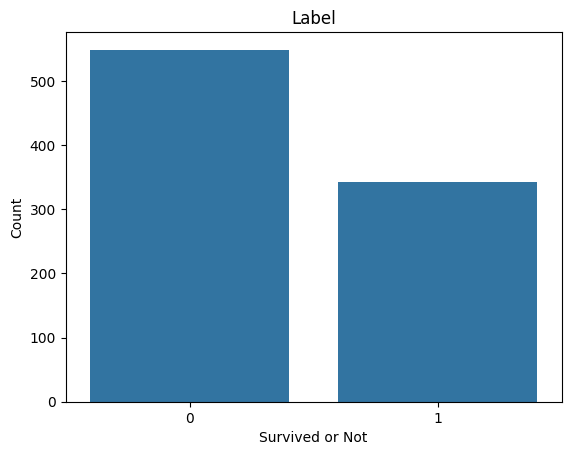

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

# 레이블 갯수 확인 (그래프)
sns.countplot(data = df, x="Survived")
plt.xlabel("Survived or Not")
plt.ylabel("Count")
plt.title("Label")

In [3]:
# 컬렴명 확인
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [4]:
# 레이블 갯수 확인
print(df['Survived'].value_counts())

Survived
0    549
1    342
Name: count, dtype: int64


In [5]:
# 결측치 확인
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# feature_selection 과정
# 머신러닝 모델은 문자열을 읽지 못함, 필요 없는 데이터 삭제 과정
# 이번 모델링은 모든 feature를 사용할 것이므로 열 제거는 하지 않음

# 결측치(빈칸) 처리 / 평균값으로 채우기(숫자 Age), 최빈값으로 채우기(문자열 or 범주형 데이터 Embarked, Cabin)
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Cabin'] = df['Cabin'].fillna(df['Cabin'].mode()[0])

# 문자열 컬럼 인코딩
# 문자열 -> 숫자 변환(유의미한 데이터)
df['Name'] = le.fit_transform(df['Name'])
df['Sex'] = le.fit_transform(df['Sex'])
df['Ticket'] = le.fit_transform(df['Ticket'])
df['Cabin'] = le.fit_transform(df['Cabin'])
df['Embarked'] = le.fit_transform(df['Embarked'])

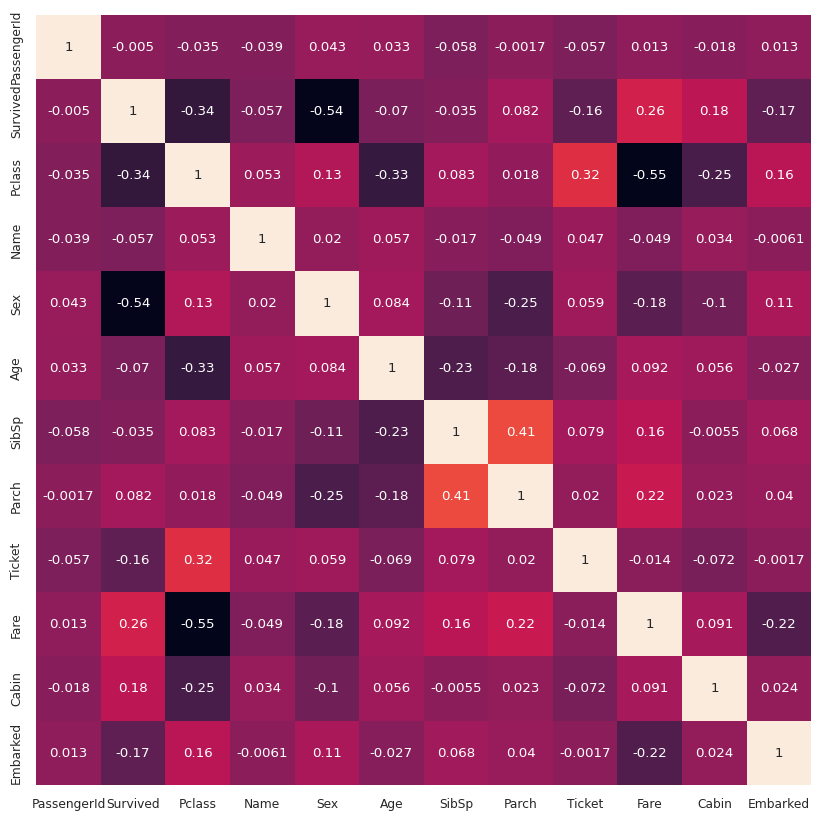

Survived       1.000000
Fare           0.257307
Cabin          0.175690
Parch          0.081629
PassengerId   -0.005007
SibSp         -0.035322
Name          -0.057343
Age           -0.069809
Ticket        -0.164549
Embarked      -0.167675
Pclass        -0.338481
Sex           -0.543351
Name: Survived, dtype: float64


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

#상관관계 히트맵
# 0.3 이상인 경우 상관관계가 있고, 0.7이상이면 아주 높음

df_corr = df.corr()

#히트맵 출력
plt.figure(figsize=(10,10))
sns.set(font_scale=0.8)
sns.heatmap(df_corr, annot=True, cbar=False)
plt.show()

# Survived와 상관관계가 높은 feature 확인
# 정답 데이터인 survived랑 만나는 지점을 읽었을 때
# 음수라면 해당 속성값이 클수록 survived일 확률이 낮다
# 0과 가깝다면 거의 상관 없는 속성이다
# 양수라면 해당 속성값이 클수록 survived일 확률이 높다
print(df_corr['Survived'].sort_values(ascending=False))

In [9]:
# y 정답 데이터 설정
y = df['Survived']
y.value_counts()
y

,Survived
0,0
1,1
2,1
3,1
4,0
...,...
886,0
887,1
888,0
889,1


In [10]:
# Survived을 예측해야하니 Survived을 제외
X = df.drop('Survived', axis=1)
X.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,3,108,1,22.0,1,0,523,7.2500,47,2
1,2,1,190,0,38.0,1,0,596,71.2833,81,0
2,3,3,353,0,26.0,0,0,669,7.9250,47,2
3,4,1,272,0,35.0,1,0,49,53.1000,55,2
4,5,3,15,1,35.0,0,0,472,8.0500,47,2


In [11]:
from sklearn.model_selection import train_test_split

# 학습 / 테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

In [12]:
# LR
# 입력 특징을 이용하여 "생존할 활률"을 계산하고, 그 확률을 기반으로 생존 여부를 확인
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

# 학습
clf_lr = LogisticRegression(random_state=0, max_iter=1000)
clf_lr.fit(X_train, y_train)

# 예측
pred_lr = clf_lr.predict(X_test)

# 모델 성능 평가
print("\n--- Logistic Regression Classifier ---")
print("정확도 :", accuracy_score(y_test, pred_lr))
print("혼동행렬 :")
print(confusion_matrix(y_test, pred_lr))


--- Logistic Regression Classifier ---
정확도 : 0.7892376681614349
혼동행렬 :
[[115  24]
 [ 23  61]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [13]:
# DT
# 입력 feature 값을 기준으로 데이터를 분할하고
# 가장 잘 클래스가 구분되는 기준을 선택하여 트리 구조로 분류하는 모델
from sklearn.tree import DecisionTreeClassifier

# 학습
clf_dt = DecisionTreeClassifier(random_state=0)
clf_dt.fit(X_train, y_train)

# 예측
pred_dt = clf_dt.predict(X_test)

# 모델 성능 평가
print("\n--- Decision Tree Classifier ---")
print("정확도 :", accuracy_score(y_test, pred_dt))
print("혼동행렬 :")
print(confusion_matrix(y_test, pred_dt))


--- Decision Tree Classifier ---
정확도 : 0.7488789237668162
혼동행렬 :
[[106  33]
 [ 23  61]]


In [14]:
# RF
# 여러 개의 Decision Tree를 학습시킨 뒤, 각 트리의 예측 결과를 종합(투표)하여 분류하는 앙상블 모델
from sklearn.ensemble import RandomForestClassifier

# 학습
clf_rf = RandomForestClassifier(random_state=0)
clf_rf.fit(X_train, y_train)

# 예측
pred_rf = clf_rf.predict(X_test)

# 모델 성능 평가
print("\n--- Random Forest Classifier ---")
print("정확도 :", accuracy_score(y_test, pred_rf))
print("혼동행렬 :")
print(confusion_matrix(y_test, pred_rf))


--- Random Forest Classifier ---
정확도 : 0.8340807174887892
혼동행렬 :
[[123  16]
 [ 21  63]]


In [15]:
# KNN
# 새로운 데이터와 가장 가까운 K개의 이웃 데이터를 찾은 뒤, 이웃들의 다수결(또는 평균)로 결과를 예측하는 모델
from sklearn.neighbors import KNeighborsClassifier

# 학습
knn = KNeighborsClassifier(n_neighbors=6)  # 주변 6개 데이터 참고
knn.fit(X_train, y_train)

# 예측
y_pred = knn.predict(X_test)

# 모델 성능 평가
print("\n--- KNeighborsClassifier ---")
print("정확도 :", accuracy_score(y_test, pred_rf))
print("혼동행렬 :")
print(confusion_matrix(y_test, pred_rf))


--- KNeighborsClassifier ---
정확도 : 0.8340807174887892
혼동행렬 :
[[123  16]
 [ 21  63]]
